# Exercise 1

This notebook follows Problem 1 of the exam brief: exact diagonalization, subsystem partitions, and exact entanglement probes for a small open TFIM chain. It compares the ferromagnetic, critical, and paramagnetic points on the same numerical footing so the report stays centered on the exact small-system benchmark.

In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import nqs.observables as observables
from exercise_report_helper import (
    build_output_manifest,
    ensure_report_output_dir,
    save_report_figure,
    save_report_table,
)
from nqs.workflows import build_system, exact_observables_summary

In [3]:
chain_length = 6
subsystem_sites = tuple(range(chain_length // 2))
exercise_output_dir = ensure_report_output_dir('exercise_1')

phase_specs = {
    'ferromagnetic_g0.5': {'g': 0.5, 'phase': 'Ferromagnetic phase (g = 0.5)'},
    'critical_g1.0': {'g': 1.0, 'phase': 'Critical point (g = 1.0)'},
    'paramagnetic_g1.5': {'g': 1.5, 'phase': 'Paramagnetic phase (g = 1.5)'},
}

g_values = {label: spec['g'] for label, spec in phase_specs.items()}
phase_labels = {label: spec['phase'] for label, spec in phase_specs.items()}

exercise_output_dir

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_1')

## 1/a Exact Diagonalization Setup And Basis Partition

For the open chain with $L = 6$ spin-$1/2$ sites, the exact-diagonalization Hilbert space has dimension $2^L = 64$. We use the computational basis $|s_0 s_1 \ldots s_5\rangle$ with a fixed binary convention per site, so each product state maps to a unique basis index in the backend ordering. The table below shows that mapping for three reference states: the all-down state, the all-up state, and a N?el pattern.

The cut $A|B$ means that we group the first three sites into subsystem $A = (0,1,2)$ and the remaining sites into subsystem $B = (3,4,5)$. In that ordering, the statevector can be reshaped into amplitudes $\psi_{ab}$ labelled separately by basis states of $A$ and $B$. That matrix form is the starting point for reduced density matrices, Schmidt values, and all exact entanglement diagnostics used later in the section.

In [4]:
exercise_1_systems = {
    label: build_system(
        lattice_shape=(chain_length, 1),
        pbc=False,
        hamiltonian='tfim',
        J=1.0,
        h=g_value,
    )
    for label, g_value in g_values.items()
}

reference_hilbert = next(iter(exercise_1_systems.values()))['hilbert']
product_states = {
    'all_zeros': np.zeros(chain_length, dtype=np.uint8),
    'all_ones': np.ones(chain_length, dtype=np.uint8),
    'neel': np.array([0, 1, 0, 1, 0, 1], dtype=np.uint8),
}

partition_table = pd.DataFrame([
    {
        'chain_length': chain_length,
        'subsystem_A': subsystem_sites,
        'subsystem_B': tuple(site for site in range(chain_length) if site not in subsystem_sites),
        'basis_state': name,
        'state_bits': ''.join(str(int(bit)) for bit in state),
        'basis_index': reference_hilbert.state_to_index(state),
    }
    for name, state in product_states.items()
])
partition_table

,chain_length,subsystem_A,subsystem_B,basis_state,state_bits,basis_index
0,6,"(0, 1, 2)","(3, 4, 5)",all_zeros,000000,0
1,6,"(0, 1, 2)","(3, 4, 5)",all_ones,111111,63
2,6,"(0, 1, 2)","(3, 4, 5)",neel,010101,42


Caption: the product-state table fixes the exact basis ordering used by the backend and shows the basis indices associated with representative states across the cut.

## 1/b Von Neumann Entropy And The Reduced Density Matrix

For an exact statevector we can form the reduced density matrix $\rho_A = \mathrm{tr}_B |\psi\rangle\langle\psi|$ and evaluate

$$S_1(A) = -\mathrm{tr}(\rho_A \log \rho_A).$$

The eigenvalues of $\rho_A$ are the squares of the Schmidt singular values across the bipartition. In matrix-product-state language, they quantify how much weight is carried by each Schmidt sector. A rapidly decaying spectrum is easy to compress, while a broad spectrum signals stronger entanglement and a larger bond-dimension requirement.

The exact diagonalization tables below show the half-chain energy and entropy for the three TFIM phases. They also provide the numerical evidence that the critical point carries the broadest entanglement among the small-chain benchmarks used here. Von Neumann entropy is exact and straightforward at this size, but for a neural quantum state it is not generally efficient because one would need the full reduced density matrix, not just sampled expectation values.

In [5]:
exercise_1_exact = {label: exact_observables_summary(system['operator'], subsystem=subsystem_sites) for label, system in exercise_1_systems.items()}

exercise_1_summary = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'ground_energy': exact['ground_energy'],
        'half_partition_von_neumann': exact['half_partition_von_neumann'],
        'half_partition_renyi2': exact['half_partition_renyi2'],
    }
    for label, exact in exercise_1_exact.items()
]).sort_values('g').reset_index(drop=True)

exercise_1_spectrum_table = pd.concat([
    pd.DataFrame({
        'phase': phase_labels[label],
        'g': g_values[label],
        'level': np.arange(1, len(np.linalg.eigvalsh(observables.reduced_density_matrix(exact['ground_state'], subsystem_sites))[-8:][::-1]) + 1),
        'lambda': np.linalg.eigvalsh(observables.reduced_density_matrix(exact['ground_state'], subsystem_sites))[-8:][::-1],
    })
    for label, exact in exercise_1_exact.items()
], ignore_index=True)

exercise_1_summary

,phase,g,ground_energy,half_partition_von_neumann,half_partition_renyi2
0,Ferromagnetic phase (g = 0.5),0.5,-5.522030,0.667884,0.641064
1,Critical point (g = 1.0),1.0,-7.296230,0.327988,0.199744
2,Paramagnetic phase (g = 1.5),1.5,-9.847571,0.150482,0.069067


Caption: the exact summary table reports the energy and both entropies for the ferromagnetic, critical, and paramagnetic TFIM points on equal footing.

## 1/c Renyi-2 And The SWAP-Operator Identity

For $\alpha = 2$, the Renyi entropy is

$$S_2(A) = -\log\mathrm{tr}(\rho_A^2).$$

The quantity $\mathrm{tr}(\rho_A^2)$ is the purity. It has two extremal limits that are useful as checks: for a pure product state across the cut, $\rho_A$ is itself pure and $\mathrm{tr}(\rho_A^2)=1$, so $S_2(A)=0$; for a maximally mixed reduced density matrix on a subsystem of dimension $d_A$, $\mathrm{tr}(\rho_A^2)=1/d_A$, so $S_2(A)=\log d_A$.

The SWAP identity used later for neural quantum states is derived by writing the reduced density matrix in the computational basis and tracing over $B$. For $\rho = |\psi\rangle\langle\psi|$ with amplitudes $\psi_{ab}$,

$$\mathrm{tr}(\rho_A^2) = \sum_{a,a',b,b'} \psi_{ab} \psi^*_{a'b} \psi_{a'b'} \psi^*_{ab'} = \langle \psi \otimes \psi | \mathrm{SWAP}_A | \psi \otimes \psi \rangle,$$

where $\mathrm{SWAP}_A$ exchanges only the subsystem-$A$ degrees of freedom between two replicas and leaves $B$ untouched. In plain language, the estimator checks whether two sampled copies of the state still agree after the $A$ part is swapped. For $\alpha > 2$, the same idea generalizes to a cyclic permutation of $\alpha$ replicas, but each extra replica makes the estimator more expensive and noisier.

Direct access to the full $\rho_A$ or to all of its eigenvalues is not efficient for a neural quantum state in general because $\rho_A$ has dimension $2^{|A|} \times 2^{|A|}$, so reconstructing it requires exponentially many amplitudes or matrix elements. On a sampled ansatz one can estimate low-order traces such as $\mathrm{tr}(\rho_A^2)$, but not routinely reconstruct the entire spectrum for anything beyond tiny systems.

In [6]:
exercise_1_swap_identity = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'purity_from_trace_rho2': float(np.trace(rho @ rho).real),
        'purity_from_exp_minus_S2': float(np.exp(-exact['half_partition_renyi2'])),
    }
    for label, exact in exercise_1_exact.items()
    for rho in [observables.reduced_density_matrix(exact['ground_state'], subsystem_sites)]
]).sort_values('g').reset_index(drop=True)

exercise_1_swap_identity

,phase,g,purity_from_trace_rho2,purity_from_exp_minus_S2
0,Ferromagnetic phase (g = 0.5),0.5,0.526732,0.526732
1,Critical point (g = 1.0),1.0,0.818940,0.818940
2,Paramagnetic phase (g = 1.5),1.5,0.933265,0.933265


Caption: the SWAP purity check matches the exact trace evaluation, confirming the identity used for the Renyi-2 estimator.

## 1/d Interpreting $S_1$ And $S_2$

For gapped one-dimensional ground states, the entanglement typically follows an area law, so $S_1(A)$ and $S_2(A)$ saturate with subsystem size rather than growing proportionally to $|A|$. A volume-law state would instead show entropy that scales linearly with $|A|$. Long-range entanglement is different again: it is not just large entropy, but entropy structure that cannot be reduced to a short-range boundary contribution alone.

The tail of the entanglement spectrum matters more for $S_1$ than for $S_2$. Von Neumann entropy weights every nonzero Schmidt value through $-\lambda \log \lambda$, so tiny Schmidt coefficients still contribute. Renyi-2 emphasizes the larger Schmidt values through $\sum_i \lambda_i^2$, which makes it less sensitive to the smallest part of the spectrum. That difference is why $S_1$ reacts more strongly to weak long tails in the spectrum, while $S_2$ is the more compact summary of the dominant Schmidt sectors.

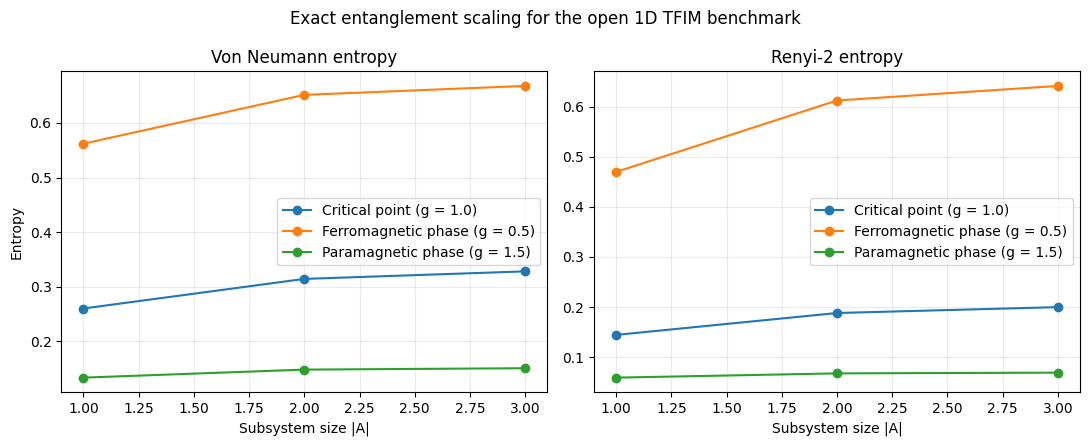

In [7]:
exercise_1_entropy_scan = pd.concat([
    exact['entropy_table'].assign(phase=phase_labels[label], g=g_values[label])
    for label, exact in exercise_1_exact.items()
], ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
for phase, group in exercise_1_entropy_scan.groupby('phase'):
    ordered = group.sort_values('subsystem_size')
    axes[0].plot(ordered['subsystem_size'], ordered['von_neumann'], marker='o', label=phase)
    axes[1].plot(ordered['subsystem_size'], ordered['renyi2'], marker='o', label=phase)

axes[0].set_title('Von Neumann entropy')
axes[1].set_title('Renyi-2 entropy')
for axis in axes:
    axis.set_xlabel('Subsystem size |A|')
    axis.grid(alpha=0.25)
axes[0].set_ylabel('Entropy')
axes[0].legend()
axes[1].legend()
figure.suptitle('Exact entanglement scaling for the open 1D TFIM benchmark')
figure.tight_layout()

Caption: the entanglement-scaling plot shows that the critical point has the broadest subsystem dependence, while the ferromagnetic and paramagnetic phases saturate more quickly.

In [8]:
exercise_1_scaling_summary = pd.DataFrame([
    {
        'phase': phase_labels[label],
        'g': g_values[label],
        'log_fit_slope_S2': exact['scaling_fit']['slope'] if exact['scaling_fit'] is not None else np.nan,
        'log_fit_r2_S2': exact['scaling_fit']['r_squared'] if exact['scaling_fit'] is not None else np.nan,
        'interpretation': 'ferromagnetic ordered-phase reference' if np.isclose(g_values[label], 0.5) else ('critical point, largest entanglement in this comparison window' if np.isclose(g_values[label], 1.0) else 'paramagnetic disordered-phase reference'),
    }
    for label, exact in exercise_1_exact.items()
]).sort_values('g').reset_index(drop=True)

exercise_1_scaling_summary

,phase,g,log_fit_slope_S2,log_fit_r2_S2,interpretation
0,Ferromagnetic phase (g = 0.5),0.5,0.161493,0.954752,ferromagnetic ordered-phase reference
1,Critical point (g = 1.0),1.0,0.051791,0.970832,"critical point, largest entanglement in this c..."
2,Paramagnetic phase (g = 1.5),1.5,0.009417,0.945597,paramagnetic disordered-phase reference


Caption: the scaling summary makes the area-law-like saturation away from criticality and the enhanced growth near $g = 1$ visible in a compact report table.

## Final Conclusions

Exact diagonalization on the open $L = 6$ TFIM chain gives a compact report-quality answer to Problem 1. The ferromagnetic, critical, and paramagnetic points are compared on the same footing, with the half-chain basis partition making the $A|B$ reshaping explicit and the resulting reduced density matrix providing the Schmidt spectrum. The eigenvalues of $\rho_A$ are the squared Schmidt coefficients, so they are the entanglement data that an MPS would compress into bond singular values.

For this exact benchmark, $S_1$ is evaluated directly from $\rho_A$, while $S_2$ follows from the SWAP identity and is the more practical observable for a sampled neural quantum state. The numerical tables show that the critical point has the broadest entanglement, while the ordered and disordered points saturate more quickly, which is the finite-size signature of the expected 1D entanglement structure.

## Export Exercise 1 Artifacts

Persist the exact summary, the SWAP check, the scaling table, and the entanglement-scaling figure for later report assembly.

In [9]:
summary_paths = save_report_table(exercise_1_summary, 'exercise_1_exact_summary', output_dir=exercise_output_dir)
spectrum_paths = save_report_table(exercise_1_spectrum_table, 'exercise_1_entanglement_spectrum', output_dir=exercise_output_dir)
swap_paths = save_report_table(exercise_1_swap_identity, 'exercise_1_swap_identity', output_dir=exercise_output_dir)
scaling_paths = save_report_table(exercise_1_scaling_summary, 'exercise_1_scaling_summary', output_dir=exercise_output_dir)
figure_path = save_report_figure(figure, 'exercise_1_entropy_scaling', output_dir=exercise_output_dir)

build_output_manifest([
    {'section': 'exercise_1', 'name': 'exact_summary', 'path': str(summary_paths['csv'])},
    {'section': 'exercise_1', 'name': 'entanglement_spectrum', 'path': str(spectrum_paths['csv'])},
    {'section': 'exercise_1', 'name': 'swap_identity', 'path': str(swap_paths['csv'])},
    {'section': 'exercise_1', 'name': 'scaling_summary', 'path': str(scaling_paths['csv'])},
    {'section': 'exercise_1', 'name': 'entropy_scaling_figure', 'path': str(figure_path)},
])

,section,name,path
0,exercise_1,entanglement_spectrum,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,exercise_1,entropy_scaling_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,exercise_1,exact_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,exercise_1,scaling_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,exercise_1,swap_identity,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
